Using file: bike_sharing_day_2026 (1).csv
Training rows: 585
Test rows: 146

MODEL 1: cnt ~ temp
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     378.3
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.56e-65
Time:                        22:02:11   Log-Likelihood:                -5110.9
No. Observations:                 585   AIC:                         1.023e+04
Df Residuals:                     583   BIC:                         1.023e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

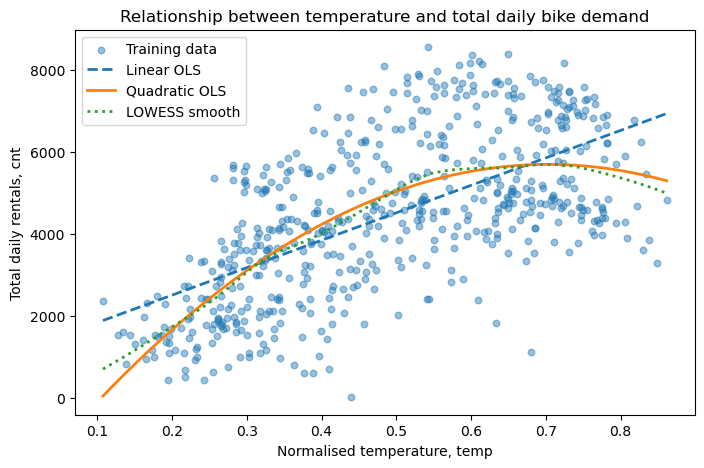

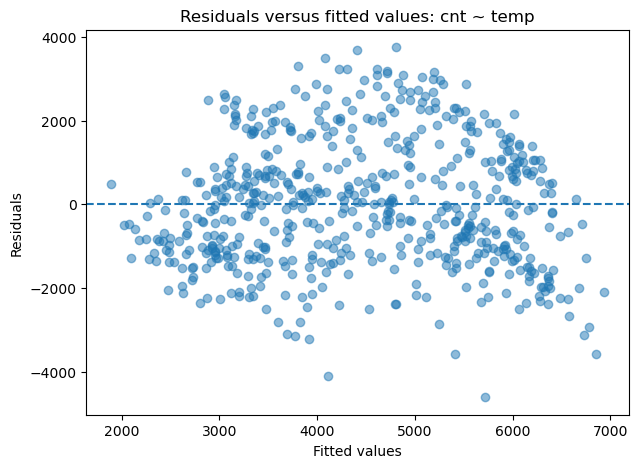

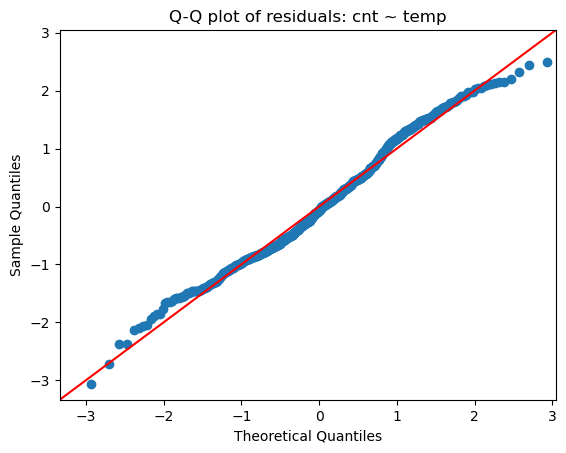


Breusch-Pagan test for heteroskedasticity
LM statistic: 5.7755
LM p-value: 0.0163
F statistic: 5.8132
F p-value: 0.0162

Correlation between temp and cnt:
0.6273

Omitted variable bias check
                    Model  Temp coefficient  R-squared
0      Simple: cnt ~ temp         6691.0477     0.3935
1              Add season         6150.7207     0.4554
2       Add season + year         5367.9655     0.7370
3  Add calendar + weather         5109.6143     0.8112


In [7]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

state = 1108224

possible_files = [
    'bike_sharing_day_2026.csv',
    'bike_sharing_day_2026 (1).csv',
    'data/bike_sharing_day_2026.csv'
]

file_found = None

for file in possible_files:
    if os.path.exists(file):
        file_found = file
        break

if file_found is None:
    print("Could not find the CSV.")
    print("Current folder:", os.getcwd())
    print("Files here:", os.listdir())
else:
    print("Using file:", file_found)

data = pd.read_csv(file_found)

train_index = data.sample(frac=0.8, random_state=state).index
train = data.loc[train_index].copy().reset_index(drop=True)
test = data.drop(train_index).copy().reset_index(drop=True)

train['log_cnt'] = np.log(train['cnt'])
train['temp2'] = train['temp'] ** 2

print("Training rows:", len(train))
print("Test rows:", len(test))


m_simple = smf.ols('cnt ~ temp', data=train).fit()
m_log = smf.ols('log_cnt ~ temp', data=train).fit()
m_quad = smf.ols('cnt ~ temp + temp2', data=train).fit()

print("\nMODEL 1: cnt ~ temp")
print(m_simple.summary())

print("\nMODEL 2: log(cnt) ~ temp")
print(m_log.summary())

print("\nMODEL 3: cnt ~ temp + temp^2")
print(m_quad.summary())

plt.figure(figsize=(8, 5))

plt.scatter(train['temp'], train['cnt'], alpha=0.45, s=22, label='Training data')

x_plot = np.linspace(train['temp'].min(), train['temp'].max(), 300)

linear_y = m_simple.params['Intercept'] + m_simple.params['temp'] * x_plot

quad_y = (
    m_quad.params['Intercept']
    + m_quad.params['temp'] * x_plot
    + m_quad.params['temp2'] * x_plot ** 2
)

lowess = sm.nonparametric.lowess(train['cnt'], train['temp'], frac=0.35)

plt.plot(x_plot, linear_y, linestyle='--', linewidth=2, label='Linear OLS')
plt.plot(x_plot, quad_y, linewidth=2, label='Quadratic OLS')
plt.plot(lowess[:, 0], lowess[:, 1], linestyle=':', linewidth=2, label='LOWESS smooth')

plt.xlabel('Normalised temperature, temp')
plt.ylabel('Total daily rentals, cnt')
plt.title('Relationship between temperature and total daily bike demand')
plt.legend()
plt.show()

# =========================
# Diagnostics
# =========================

plt.figure(figsize=(7, 5))
plt.scatter(m_simple.fittedvalues, m_simple.resid, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals versus fitted values: cnt ~ temp')
plt.show()

sm.qqplot(m_simple.resid, line='45', fit=True)
plt.title('Q-Q plot of residuals: cnt ~ temp')
plt.show()

bp_test = het_breuschpagan(m_simple.resid, m_simple.model.exog)

print("\nBreusch-Pagan test for heteroskedasticity")
print("LM statistic:", round(bp_test[0], 4))
print("LM p-value:", round(bp_test[1], 4))
print("F statistic:", round(bp_test[2], 4))
print("F p-value:", round(bp_test[3], 4))

print("\nCorrelation between temp and cnt:")
print(round(train[['temp', 'cnt']].corr().iloc[0, 1], 4))

models = {
    "Simple: cnt ~ temp": smf.ols('cnt ~ temp', data=train).fit(),
    "Add season": smf.ols('cnt ~ temp + C(season)', data=train).fit(),
    "Add season + year": smf.ols('cnt ~ temp + C(season) + C(yr)', data=train).fit(),
    "Add calendar + weather": smf.ols(
        'cnt ~ temp + C(season) + C(yr) + C(workingday) + C(weathersit) + hum + windspeed',
        data=train
    ).fit()
}

ovb_table = pd.DataFrame({
    "Model": list(models.keys()),
    "Temp coefficient": [model.params.get("temp") for model in models.values()],
    "R-squared": [model.rsquared for model in models.values()]
})

print("\nOmitted variable bias check")
print(ovb_table.round(4))

## Analysis

| Diagnostic area | Model 1: `cnt ~ temp` | Model 2: `log(cnt) ~ temp` |
| --- | --- | --- |
| R-squared | 0.394 | 0.353 |
| Residual normality | Good | Poor |
| Homoscedasticity | Mild concern | Worse |
| Linearity | Some non-linear pattern | Similar issue remains |
| Verdict | Preferred | Not justified here |

**Preferred simple model:** `cnt ~ temp`.

The scatter plot shows a clear positive relationship between temperature and total daily bike demand. As `temp` increases, `cnt` generally increases as well. However, the relationship does not appear perfectly linear. The LOWESS smoother and quadratic fit suggest some curvature, meaning the effect of temperature may weaken or flatten at higher temperatures.

The simple linear model shows that `temp` is positively associated with total daily rentals. In practical terms, warmer days tend to have higher bike demand. However, this should not be interpreted causally because the simple model does not control for other important variables.

The model assumptions only appear to hold partially. The residual plot suggests some non-linearity and possible heteroskedasticity. The Q-Q plot suggests the residuals are reasonably close to normal for the simple model, although not perfect. The log model is not clearly preferred here because it reduces model fit and appears to worsen the residual normality.

The simple relationship is likely affected by omitted variable bias. Temperature is strongly related to season, year and weather conditions. Warmer days are more likely to occur in spring and summer, when demand may also be higher because of longer daylight hours, tourism and outdoor activity. Weather variables such as humidity, windspeed and weather situation may also affect demand and be correlated with temperature.

Overall, the analysis suggests that temperature has a strong positive association with total daily bike rentals, but the relationship is not perfectly linear and should not be interpreted as causal without further controls.